# ASR Baseline Evaluation — Диалектный корпус

**Цель:** измерить WER/CER системы Whisper large-v3 на трёх доменах до конверсии:
- `don_dialect` — донская диалектная речь (7 дикторов)
- `pyoza_dialect` — пёзская диалектная речь (8 дикторов)
- `standard` — нормативная речь (интервьюеры + LibriSpeech)

**Тестовая выборка:** 710 записей (~50 мин)

**Метрики:** WER (Word Error Rate), CER (Character Error Rate)

## 0. Установка зависимостей

In [ ]:
!pip install -q openai-whisper jiwer
!pip install -q --upgrade numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 18.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 103.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


## 1. Монтирование Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Укажите свои пути ──────────────────────────────────────────────────────
DRIVE_ROOT    = '/content/drive/MyDrive/diploma'   # корень проекта на Drive
CORPUS_ROOT   = f'{DRIVE_ROOT}/corpus_22k'         # папка с предобработанным аудио
MANIFEST_PATH = f'{CORPUS_ROOT}/manifest_clean_partial.csv' # итоговый манифест
RESULTS_DIR   = f'{DRIVE_ROOT}/asr_results'        # куда сохранять результаты
# ──────────────────────────────────────────────────────────────────────────

import os
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')

Results will be saved to: /content/drive/MyDrive/diploma/asr_results


## 2. Загрузка манифеста и подготовка тестовой выборки

In [ ]:
import pandas as pd
import re

df = pd.read_csv(MANIFEST_PATH)
print(f'Всего записей в манифесте: {len(df)}')
print(df['domain_id'].value_counts())

Всего записей в манифесте: 14432
domain_id
don_dialect      6584
standard         3950
pyoza_dialect    3898
Name: count, dtype: int64


In [ ]:
# Берём только тестовый сплит
test_df = df[df['split'] == 'test'].copy().reset_index(drop=True)
print(f'Тестовых записей: {len(test_df)}')
print(test_df['domain_id'].value_counts())

Тестовых записей: 710
domain_id
don_dialect      327
standard         196
pyoza_dialect    187
Name: count, dtype: int64


In [ ]:
def normalize_transcript(text: str) -> str:
    """Нормализация транскрипта для корректного расчёта WER.

    Шаги:
    1. Приведение к нижнему регистру
    2. Удаление [нрзб], [топоним] и прочих аннотаций в скобках
    3. Удаление знаков препинания (кроме дефиса внутри слов)
    4. Нормализация пробелов
    5. Удаление маркеров обрыва слова (=) и паузы (в=)
    """
    if not isinstance(text, str):
        return ''
    t = text.lower()
    # Удаляем аннотации в квадратных скобках: [нрзб], [топоним] и т.д.
    t = re.sub(r'\[.*?\]', '', t)
    # Удаляем маркеры обрыва слова: "кис=" -> "кис"
    t = re.sub(r'=', '', t)
    # Удаляем знаки препинания, кроме дефиса внутри слов
    t = re.sub(r'[^\w\s\-]', ' ', t, flags=re.UNICODE)
    # Дефис отдельно стоящий — убираем
    t = re.sub(r'(?<![\w])\-(?![\w])', ' ', t)
    # Нормализуем пробелы
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Применяем нормализацию
test_df['ref_normalized'] = test_df['transcript'].apply(normalize_transcript)

# Убираем записи с пустым референсом после нормализации
empty_ref = test_df['ref_normalized'].str.strip() == ''
print(f'Записей с пустым референсом после нормализации: {empty_ref.sum()} — исключаем')
test_df = test_df[~empty_ref].reset_index(drop=True)
print(f'Итого для оценки: {len(test_df)}')

# Покажем примеры нормализации
print('\nПримеры нормализации:')
sample = test_df[test_df['transcript'].str.contains(r'[\[=]', na=False)].head(3)
for _, row in sample.iterrows():
    print(f'  ДО:    {row["transcript"]}')
    print(f'  ПОСЛЕ: {row["ref_normalized"]}')
    print()

Записей с пустым референсом после нормализации: 0 — исключаем
Итого для оценки: 710

Примеры нормализации:
  ДО:    Вот четверо дете= трое было детей.
  ПОСЛЕ: вот четверо дете трое было детей

  ДО:    А до= это же, мороз хороший, заволокло, ну и сильный лёд.
  ПОСЛЕ: а до это же мороз хороший заволокло ну и сильный лёд

  ДО:    И се= и медсестра, и, и у= уборщица, и все шишки на ней были.
  ПОСЛЕ: и се и медсестра и и у уборщица и все шишки на ней были



## 3. Загрузка модели Whisper

In [ ]:
import whisper
import torch

print(f'CUDA доступен: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# large-v3 — лучшее качество для русского
# Если не хватает памяти GPU — используйте 'medium'
MODEL_SIZE = 'large-v3'
model = whisper.load_model(MODEL_SIZE)
print(f'Модель {MODEL_SIZE} загружена')

CUDA доступен: True
GPU: Tesla T4


100%|██████████████████████████████████████| 2.88G/2.88G [00:25<00:00, 123MiB/s]


Модель large-v3 загружена


## 4. Транскрибирование

In [ ]:
import os
from tqdm.notebook import tqdm

def transcribe_batch(df: pd.DataFrame,
                     corpus_root: str,
                     model,
                     checkpoint_path: str = None) -> pd.DataFrame:
    """Транскрибирует все записи, сохраняет чекпоинт на Drive."""

    results = []
    errors  = []

    # Whisper options — фиксируем язык ru, без beam search для скорости
    options = whisper.DecodingOptions(
        language='ru',
        without_timestamps=True,
        fp16=torch.cuda.is_available()
    )

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Transcribing'):
        audio_path = os.path.join(corpus_root, row['rel_path'])

        if not os.path.exists(audio_path):
            errors.append({'utterance_id': row['utterance_id'],
                           'error': 'file_not_found'})
            continue

        try:
            result = model.transcribe(
                audio_path,
                language='ru',
                without_timestamps=True,
                fp16=torch.cuda.is_available()
            )
            hyp_raw = result['text'].strip()
            hyp_norm = normalize_transcript(hyp_raw)

            results.append({
                'utterance_id':   row['utterance_id'],
                'speaker_id':     row['speaker_id'],
                'domain_id':      row['domain_id'],
                'dialect_group':  row['dialect_group'],
                'duration_sec':   row['duration_sec'],
                'snr_db':         row['snr_db'],
                'reference':      row['ref_normalized'],
                'hypothesis_raw': hyp_raw,
                'hypothesis':     hyp_norm,
            })
        except Exception as e:
            errors.append({'utterance_id': row['utterance_id'], 'error': str(e)})

    results_df = pd.DataFrame(results)

    # Сохраняем чекпоинт
    if checkpoint_path:
        results_df.to_csv(checkpoint_path, index=False)
        print(f'Чекпоинт сохранён: {checkpoint_path}')

    if errors:
        print(f'Ошибок при транскрибировании: {len(errors)}')
        for e in errors[:5]:
            print(f'  {e}')

    return results_df


CHECKPOINT = f'{RESULTS_DIR}/transcriptions_raw.csv'

# Если чекпоинт уже есть — загружаем, не транскрибируем повторно
if os.path.exists(CHECKPOINT):
    print(f'Найден чекпоинт, загружаем: {CHECKPOINT}')
    results_df = pd.read_csv(CHECKPOINT)
else:
    results_df = transcribe_batch(
        test_df,
        corpus_root=CORPUS_ROOT,
        model=model,
        checkpoint_path=CHECKPOINT
    )

print(f'Транскрибировано: {len(results_df)} записей')

Transcribing:   0%|          | 0/710 [00:00<?, ?it/s]

Чекпоинт сохранён: /content/drive/MyDrive/diploma/asr_results/transcriptions_raw.csv
Транскрибировано: 710 записей


## 5. Расчёт WER / CER

In [ ]:
from jiwer import wer, cer

def compute_metrics_per_row(df: pd.DataFrame) -> pd.DataFrame:
    """Считаем WER/CER для каждой записи."""
    df = df.copy()
    wers, cers = [], []
    for _, row in df.iterrows():
        ref = row['reference']
        hyp = row['hypothesis']
        # Защита от пустых строк (jiwer падает на них)
        if not ref or not hyp:
            wers.append(1.0)
            cers.append(1.0)
        else:
            wers.append(min(wer(ref, hyp), 1.0))   # cap at 1.0
            cers.append(min(cer(ref, hyp), 1.0))
    df['wer'] = wers
    df['cer'] = cers
    return df

results_df = compute_metrics_per_row(results_df)

# Сохраняем с метриками
results_df.to_csv(f'{RESULTS_DIR}/transcriptions_with_metrics.csv', index=False)
print('Метрики рассчитаны и сохранены.')

Метрики рассчитаны и сохранены.


## 6. Агрегированные результаты

In [ ]:
import numpy as np

def aggregate_metrics(df: pd.DataFrame, groupby: str) -> pd.DataFrame:
    """WER/CER по группам. Считаем как среднее по записям."""
    agg = df.groupby(groupby).agg(
        n_utterances   = ('wer', 'count'),
        total_dur_min  = ('duration_sec', lambda x: round(x.sum()/60, 1)),
        WER_mean       = ('wer', lambda x: round(x.mean()*100, 1)),
        WER_median     = ('wer', lambda x: round(x.median()*100, 1)),
        CER_mean       = ('cer', lambda x: round(x.mean()*100, 1)),
        CER_median     = ('cer', lambda x: round(x.median()*100, 1)),
    ).reset_index()
    return agg

# По доменам
by_domain = aggregate_metrics(results_df, 'domain_id')
print('=== WER/CER по доменам (%%) ===')
print(by_domain.to_string(index=False))

print()

# По дикторам
by_speaker = aggregate_metrics(results_df, 'speaker_id')
print('=== WER/CER по дикторам (%%) ===')
print(by_speaker.to_string(index=False))

=== WER/CER по доменам (%%) ===
    domain_id  n_utterances  total_dur_min  WER_mean  WER_median  CER_mean  CER_median
  don_dialect           327           19.9      33.0        27.3      19.6        12.5
pyoza_dialect           187           17.6      52.8        52.9      31.7        28.5
     standard           196           13.3      21.6         8.7      15.7         2.2

=== WER/CER по дикторам (%%) ===
       speaker_id  n_utterances  total_dur_min  WER_mean  WER_median  CER_mean  CER_median
      don_EIV1939            61            4.0      26.9        23.1      14.2        10.5
      don_GLT1934            40            2.1      38.6        38.8      22.3        14.3
      don_KVA1948            44            2.9      25.3        20.0      16.3         8.2
      don_MLI1941            36            1.9      21.1        16.7      14.2         8.1
      don_SVS1939            18            1.0      30.2        25.0      19.6         9.3
      don_TNG1957            74         

In [ ]:
# Corpus-level WER (классический: сумма ошибок / сумма слов)
# Для него нужно посчитать количество слов в референсе

from jiwer import process_words

def corpus_wer(df: pd.DataFrame) -> float:
    """Corpus-level WER = общее число ошибок / общее число слов референса."""
    total_errors = 0
    total_words  = 0
    for _, row in df.iterrows():
        ref = row['reference']
        hyp = row['hypothesis']
        if not ref:
            continue
        out = process_words(ref, hyp)
        total_errors += out.substitutions + out.deletions + out.insertions
        total_words  += len(ref.split())
    return total_errors / total_words if total_words > 0 else 1.0

print('=== Corpus-level WER (%) ===')
for domain in results_df['domain_id'].unique():
    sub = results_df[results_df['domain_id'] == domain]
    cw = corpus_wer(sub)
    print(f'  {domain:<20}: {cw*100:.1f}%')

print(f'  {"TOTAL":<20}: {corpus_wer(results_df)*100:.1f}%')

=== Corpus-level WER (%) ===
  don_dialect         : 35.0%
  standard            : 20.1%
  pyoza_dialect       : 54.1%
  TOTAL               : 38.1%


## 7. Анализ ошибок

In [ ]:
# Самые сложные записи (топ-20 по WER)
worst = results_df.nlargest(20, 'wer')[['domain_id','speaker_id','wer','cer','reference','hypothesis_raw']]
print('=== Топ-20 записей по WER ===')
for _, row in worst.iterrows():
    print(f'[{row["domain_id"]} | {row["speaker_id"]}] WER={row["wer"]*100:.0f}%')
    print(f'  REF: {row["reference"]}')
    print(f'  HYP: {row["hypothesis_raw"]}')
    print()

=== Топ-20 записей по WER ===
[don_dialect | don_EIV1939] WER=100%
  REF: я его собирал когда
  HYP: Сейчас там...

[don_dialect | don_EIV1939] WER=100%
  REF: пусть козочки да три праздники же как как троица же
  HYP: Три дня должна постоять в церкви, да? Не сразу можно. Праздники же, как троицы.

[don_dialect | don_GLT1934] WER=100%
  REF: начали кормить там
  HYP: Иversein firmite PM.

[don_dialect | don_GLT1934] WER=100%
  REF: тут каждая копейка на счету была
  HYP: Субтитры делал DimaTorzok

[don_dialect | don_KVA1948] WER=100%
  REF: даже дачник вот этот купил
  HYP: Даже доченьку этот купил, у него был.

[don_dialect | don_KVA1948] WER=100%
  REF: большая кровать у нас была
  HYP: У нас была большая кровать, но не было.

[don_dialect | don_MLI1941] WER=100%
  REF: жарим блины на масленицу
  HYP: А сколько дней? Единственное, что я не знаю,

[don_dialect | don_SVS1939] WER=100%
  REF: да что ты за зараза-то такая иди домой
  HYP: Вот здесь зараза, это пока и...

[don_dialect | d

/tmp/ipykernel_1946/2233165809.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=domain_labels,
/tmp/ipykernel_1946/2233165809.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=domain_labels,


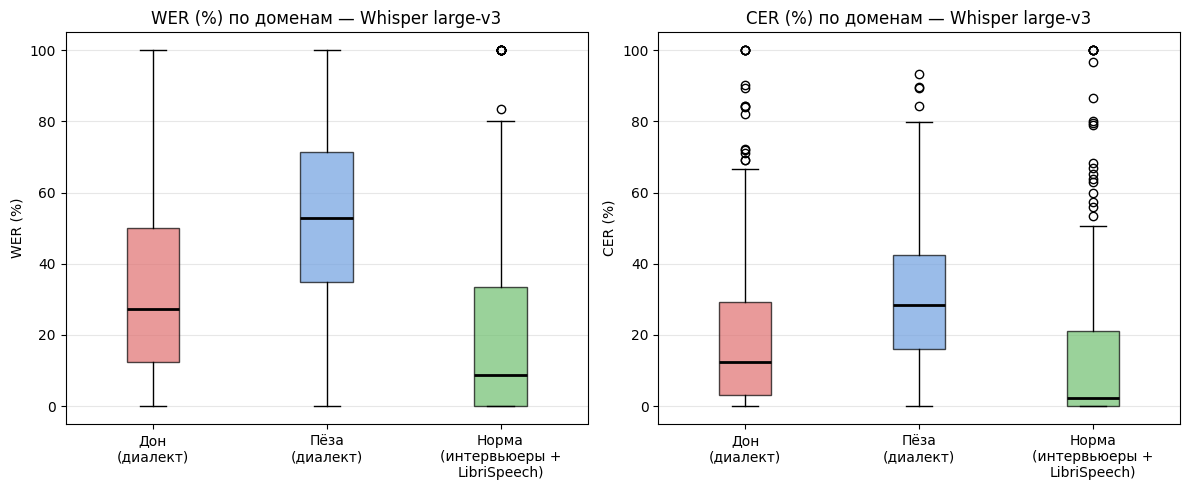

График сохранён.


In [ ]:
# Распределение WER по доменам — боксплот
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

domain_order = ['don_dialect', 'pyoza_dialect', 'standard']
domain_labels = ['Дон\n(диалект)', 'Пёза\n(диалект)', 'Норма\n(интервьюеры +\nLibriSpeech)']
colors = ['#E07070', '#70A0E0', '#70C070']

for ax, metric, title in zip(axes, ['wer', 'cer'], ['WER (%)', 'CER (%)']):
    data = [results_df[results_df['domain_id'] == d][metric].values * 100
            for d in domain_order]
    bp = ax.boxplot(data, patch_artist=True, labels=domain_labels,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{title} по доменам — Whisper large-v3', fontsize=12)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/wer_cer_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён.')

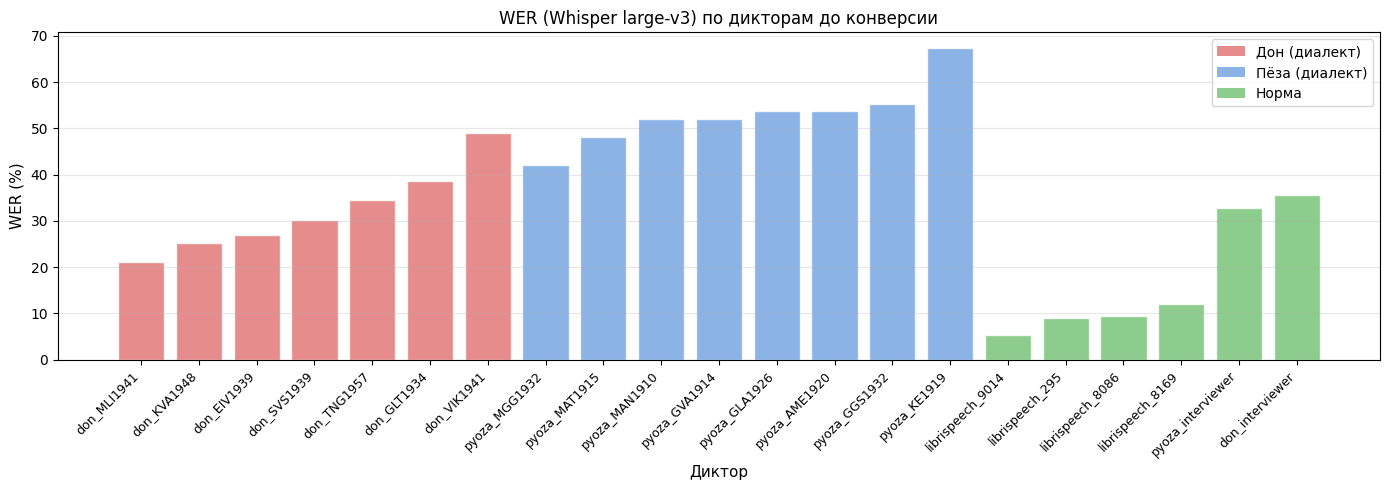

In [ ]:
# WER по дикторам
fig, ax = plt.subplots(figsize=(14, 5))

spk_wer = (results_df.groupby(['domain_id','speaker_id'])['wer']
           .mean() * 100).reset_index()
spk_wer = spk_wer.sort_values(['domain_id', 'wer'])

color_map = {'don_dialect': '#E07070', 'pyoza_dialect': '#70A0E0', 'standard': '#70C070'}
bar_colors = [color_map[d] for d in spk_wer['domain_id']]

bars = ax.bar(spk_wer['speaker_id'], spk_wer['wer'],
              color=bar_colors, alpha=0.8, edgecolor='white')

ax.set_xlabel('Диктор', fontsize=11)
ax.set_ylabel('WER (%)', fontsize=11)
ax.set_title('WER (Whisper large-v3) по дикторам до конверсии', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, alpha=0.8, label=l)
                   for c, l in zip(['#E07070','#70A0E0','#70C070'],
                                   ['Дон (диалект)','Пёза (диалект)','Норма'])]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/wer_by_speaker.png', dpi=150, bbox_inches='tight')
plt.show()

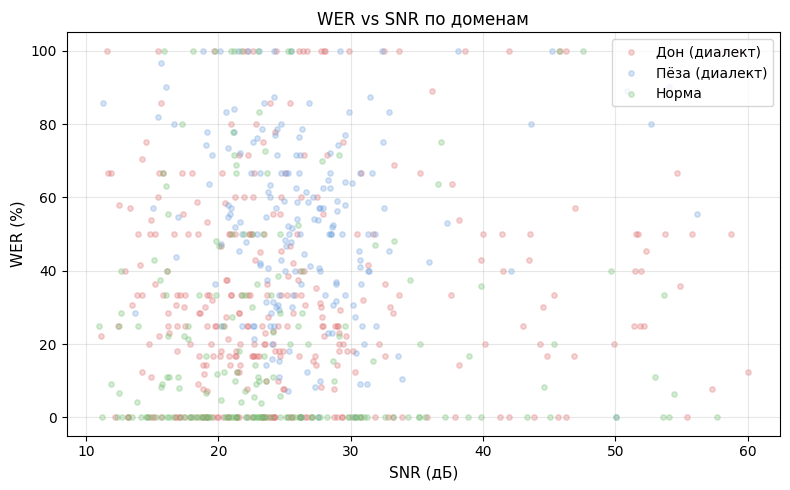

In [ ]:
# WER vs SNR — есть ли корреляция?
fig, ax = plt.subplots(figsize=(8, 5))

for domain, color, label in zip(
    domain_order, colors,
    ['Дон (диалект)', 'Пёза (диалект)', 'Норма']
):
    sub = results_df[results_df['domain_id'] == domain]
    ax.scatter(sub['snr_db'], sub['wer']*100,
               alpha=0.3, s=15, color=color, label=label)

ax.set_xlabel('SNR (дБ)', fontsize=11)
ax.set_ylabel('WER (%)', fontsize=11)
ax.set_title('WER vs SNR по доменам', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/wer_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Сводная таблица для ВКР

In [ ]:
# Финальная сводка
summary = by_domain[['domain_id','n_utterances','total_dur_min',
                      'WER_mean','WER_median','CER_mean','CER_median']].copy()
summary.columns = ['Домен', 'Записей', 'Длит. (мин)',
                   'WER средн.%', 'WER медиана%',
                   'CER средн.%', 'CER медиана%']
print('=== Сводная таблица результатов ASR (Whisper large-v3) ===')
print(summary.to_string(index=False))

# Сохраняем как CSV
summary.to_csv(f'{RESULTS_DIR}/summary_table.csv', index=False)

# Нормализованное «расстояние до нормы» для последующего сравнения с пост-конверсией
wer_standard = results_df[results_df['domain_id']=='standard']['wer'].mean()
print(f'\nWER нормативного домена (floor): {wer_standard*100:.1f}%')
print('Это значение использовать как W_C в формуле нормализованного улучшения.')
print('Когда получим результаты после конверсии:')
print('  Improvement = (WER_dialect - WER_converted) / (WER_dialect - WER_standard)')

=== Сводная таблица результатов ASR (Whisper large-v3) ===
        Домен  Записей  Длит. (мин)  WER средн.%  WER медиана%  CER средн.%  CER медиана%
  don_dialect      327         19.9         33.0          27.3         19.6          12.5
pyoza_dialect      187         17.6         52.8          52.9         31.7          28.5
     standard      196         13.3         21.6           8.7         15.7           2.2

WER нормативного домена (floor): 21.6%
Это значение использовать как W_C в формуле нормализованного улучшения.
Когда получим результаты после конверсии:
  Improvement = (WER_dialect - WER_converted) / (WER_dialect - WER_standard)


## 9. Качественный анализ: примеры для ВКР

In [ ]:
# Отбираем характерные примеры — хорошо распознанные и плохо распознанные
# по каждому диалекту
print('=== Примеры из донского корпуса (диапазон WER) ===\n')
don_samples = results_df[results_df['domain_id']=='don_dialect'].copy()

# 3 успешных (WER < 0.2)
good = don_samples[don_samples['wer'] < 0.2].sample(min(3, len(don_samples[don_samples['wer']<0.2])), random_state=42)
print('-- Хорошо распознанные (WER < 20%): --')
for _, row in good.iterrows():
    print(f'  [{row["speaker_id"]}] WER={row["wer"]*100:.0f}%')
    print(f'  REF: {row["reference"]}')
    print(f'  HYP: {row["hypothesis_raw"]}')
    print()

# 3 плохих (WER > 0.6)
bad = don_samples[don_samples['wer'] > 0.6].sample(min(3, len(don_samples[don_samples['wer']>0.6])), random_state=42)
print('-- Плохо распознанные (WER > 60%): --')
for _, row in bad.iterrows():
    print(f'  [{row["speaker_id"]}] WER={row["wer"]*100:.0f}%')
    print(f'  REF: {row["reference"]}')
    print(f'  HYP: {row["hypothesis_raw"]}')
    print()

print('\n=== Примеры из пёзского корпуса (диапазон WER) ===\n')
pyo_samples = results_df[results_df['domain_id']=='pyoza_dialect'].copy()

bad_pyo = pyo_samples[pyo_samples['wer'] > 0.6].sample(min(3, len(pyo_samples[pyo_samples['wer']>0.6])), random_state=42)
print('-- Плохо распознанные (WER > 60%): --')
for _, row in bad_pyo.iterrows():
    print(f'  [{row["speaker_id"]}] WER={row["wer"]*100:.0f}%')
    print(f'  REF: {row["reference"]}')
    print(f'  HYP: {row["hypothesis_raw"]}')
    print()

=== Примеры из донского корпуса (диапазон WER) ===

-- Хорошо распознанные (WER < 20%): --
  [don_MLI1941] WER=0%
  REF: а завтра какой день
  HYP: А завтра какой день?

  [don_TNG1957] WER=17%
  REF: вот это вот дальше напечатано а морюшко на мотив точно такой же
  HYP: Вот это вот дальше напечатано, а морюшка, мотив точно такой же.

  [don_EIV1939] WER=0%
  REF: вот неслись раз а тут лодку вырубили
  HYP: Вот неслись раз, а тут лодку вырубили.

-- Плохо распознанные (WER > 60%): --
  [don_VIK1941] WER=69%
  REF: раньше же вот тут колхозная мельница молола крупу-то с чего с чего кашу-то с чего варили
  HYP: Раньше жил тут колхозная мельница, молола, крупную тащил, тащил, вальфу тащил вальф.

  [don_VIK1941] WER=100%
  REF: чистили и ели
  HYP: Истребление.

  [don_VIK1941] WER=100%
  REF: мы посадили уже уродила кукуруза
  HYP: Что в Паттадире не уродилось у кормиша?


=== Примеры из пёзского корпуса (диапазон WER) ===

-- Плохо распознанные (WER > 60%): --
  [pyoza_MAN1910] WER=62%
 

In [ ]:
print('\n=== Все результаты сохранены в:', RESULTS_DIR, '===')
print('Файлы:')
for f in os.listdir(RESULTS_DIR):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f'  {f}  ({size/1024:.1f} KB)')


=== Все результаты сохранены в: /content/drive/MyDrive/diploma/asr_results ===
Файлы:
  transcriptions_raw.csv  (267.3 KB)
  transcriptions_with_metrics.csv  (285.2 KB)
  wer_cer_by_domain.png  (60.7 KB)
  wer_by_speaker.png  (105.6 KB)
  wer_vs_snr.png  (110.2 KB)
  summary_table.csv  (0.2 KB)


In [ ]:

std = results_df[results_df['domain_id'] == 'standard'].copy()

# Подгруппы: чистая нормативная речь (LibriSpeech) и разговорная (интервьюеры)
librispeech  = std[std['speaker_id'].str.startswith('librispeech')]
interviewers = std[std['speaker_id'].str.startswith('don_interviewer') |
                   std['speaker_id'].str.startswith('pyoza_interviewer')]

N = 4  # сколько примеров показывать на категорию

def show_examples(df, label, n=N):
    print(f'\n{"─"*70}')
    print(f' {label}  (записей: {len(df)}, WER средн.: {df["wer"].mean()*100:.1f}%)')
    print(f'{"─"*70}')
    # Хорошо распознанные — n с наименьшим WER
    good = df.nsmallest(n, 'wer')
    print(f'\n  ✓ Хорошо распознанные (наименьший WER):')
    for _, r in good.iterrows():
        print(f'\n    [{r["speaker_id"]}]  WER={r["wer"]*100:.0f}%  CER={r["cer"]*100:.0f}%  '
              f'dur={r["duration_sec"]:.1f}с  SNR={r["snr_db"]:.0f}дБ')
        print(f'    REF: {r["reference"]}')
        print(f'    HYP: {r["hypothesis_raw"]}')
    # Плохо распознанные — n с наибольшим WER
    bad = df.nlargest(n, 'wer')
    print(f'\n  ✗ Плохо распознанные (наибольший WER):')
    for _, r in bad.iterrows():
        print(f'\n    [{r["speaker_id"]}]  WER={r["wer"]*100:.0f}%  CER={r["cer"]*100:.0f}%  '
              f'dur={r["duration_sec"]:.1f}с  SNR={r["snr_db"]:.0f}дБ')
        print(f'    REF: {r["reference"]}')
        print(f'    HYP: {r["hypothesis_raw"]}')

show_examples(librispeech,  'LIBRISPEECH — книжная нормативная речь')
show_examples(interviewers, 'ИНТЕРВЬЮЕРЫ — разговорная нормативная речь')

# ── Сводка ──────────────────────────────────────────────────────────────────
print(f'\n{"═"*70}')
print(f'  ИТОГО стандартный домен')
print(f'{"═"*70}')
print(f'  LibriSpeech   :  n={len(librispeech):3d}  '
      f'WER {librispeech["wer"].mean()*100:.1f}%  '
      f'CER {librispeech["cer"].mean()*100:.1f}%')
print(f'  Интервьюеры   :  n={len(interviewers):3d}  '
      f'WER {interviewers["wer"].mean()*100:.1f}%  '
      f'CER {interviewers["cer"].mean()*100:.1f}%')
print(f'  Стандарт всего:  n={len(std):3d}  '
      f'WER {std["wer"].mean()*100:.1f}%  '
      f'CER {std["cer"].mean()*100:.1f}%')


──────────────────────────────────────────────────────────────────────
 LIBRISPEECH — книжная нормативная речь  (записей: 98, WER средн.: 9.0%)
──────────────────────────────────────────────────────────────────────

  ✓ Хорошо распознанные (наименьший WER):

    [librispeech_295]  WER=0%  CER=0%  dur=4.3с  SNR=23дБ
    REF: я прежде служил а теперь не служу я был злой чиновник
    HYP: Я прежде служил, а теперь не служу. Я был злой чиновник.

    [librispeech_295]  WER=0%  CER=0%  dur=4.9с  SNR=23дБ
    REF: человек же с характером деятель существом по преимуществу ограниченным
    HYP: Человек же с характером, деятель, существом по преимуществу ограниченным.

    [librispeech_295]  WER=0%  CER=0%  dur=2.6с  SNR=23дБ
    REF: города бывают умышленные и неумышленные
    HYP: Города бывают умышленные и неумышленные.

    [librispeech_295]  WER=0%  CER=0%  dur=6.8с  SNR=28дБ
    REF: они не пощадили ничего ни колонн ни карнизов и мой приятель пожелтел как канарейка
    HYP: Они не пощади

In [ ]:
HALLUCINATION_PATTERNS = [
    r'субтитр',
    r'dima\s*torzok',
    r'подписыва',
    r'продолжение следует',
    r'редактировал',
    r'поставьте лайк',
    r'^\s*$',           # пустая строка
]

def is_hallucination(text: str) -> bool:
    if not isinstance(text, str) or text.strip() == '':
        return True
    t = text.lower()
    return any(re.search(p, t) for p in HALLUCINATION_PATTERNS)

results_df['is_hallucination'] = results_df['hypothesis_raw'].apply(is_hallucination)

n_hall = results_df['is_hallucination'].sum()
print(f'Галлюцинаций обнаружено: {n_hall} ({n_hall/len(results_df)*100:.1f}%)')

# Для WER-расчётов исключать или помечать отдельно
results_clean = results_df[~results_df['is_hallucination']]

Галлюцинаций обнаружено: 2 (0.3%)
